# Case Richness → Sentence Length → DDM Rank Shifts

**Linking Mechanism Analysis** across Universal Dependencies treebanks.

This notebook tests whether case-rich languages have longer sentences AND larger rank shifts between naive and standardized Dependency Distance Minimization (DDM) metrics. It computes:
- Spearman/Pearson correlations with bootstrap CIs
- Mediation-style OLS regressions
- Group-level (binned case richness) Kruskal-Wallis tests
- Language family analysis
- Robustness checks on well-attested treebanks

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All packages used are pre-installed on Colab; install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0', 'statsmodels==0.14.6')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import os

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import kruskal, pearsonr, spearmanr
import statsmodels.api as sm
import matplotlib.pyplot as plt

## Load Data

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-3bc3de-sentence-length-standardization-reveals-/main/experiment_iter2_case_length_ddm/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['examples'])} treebank records")

Loaded 50 treebank records


## Configuration

In [5]:
# Number of bootstrap resamples for confidence intervals
# Original: 10000 — reduced for demo speed
N_BOOTSTRAP = 500

# Minimum sentences for robustness subset
MIN_SENTENCES_ROBUST = 100

## Build DataFrame from Examples

In [6]:
# Parse input/output JSON strings into a flat DataFrame
records = []
for ex in data["examples"]:
    inp = json.loads(ex["input"])
    out = json.loads(ex["output"])
    records.append({**inp, **out})

df = pd.DataFrame(records)

# Create shorthand columns
df["cr"] = pd.to_numeric(df["case_richness"], errors="coerce").fillna(0)
df["msl"] = pd.to_numeric(df["mean_sentence_length"], errors="coerce")
df["naive"] = pd.to_numeric(df["naive_ddm"], errors="coerce")
df["std"] = pd.to_numeric(df["standardized_ddm"], errors="coerce")

# Compute rank shifts on the demo subset
df["naive_rank"] = df["naive"].rank(ascending=False, method="average")
df["std_rank"] = df["std"].rank(ascending=False, method="average")
df["abs_rank_shift"] = (df["naive_rank"] - df["std_rank"]).abs()
df["signed_rank_shift"] = df["naive_rank"] - df["std_rank"]

print(f"DataFrame shape: {df.shape}")
df[["treebank_id", "cr", "msl", "naive", "std", "abs_rank_shift"]].head(10)

DataFrame shape: (50, 14)


,treebank_id,cr,msl,naive,std,abs_rank_shift
0,ab_abnc,0,7.84,0.2992,0.2444,1.0
1,akk_riao,3,10.27,0.3187,0.2954,4.0
2,ar_pud,3,19.74,0.5273,0.3434,9.0
3,be_hse,7,12.32,0.3523,0.4059,20.0
4,bor_bdt,0,7.75,0.2797,0.4194,31.0
5,ckt_hse,0,5.98,0.1872,0.1197,9.0
6,cs_fictree,4,13.16,0.3134,0.3399,11.0
7,cy_ccg,0,19.21,0.4978,0.3847,1.0
8,egy_ujaen,5,9.82,0.3907,0.4086,16.0
9,eme_tudet,2,4.10,0.1093,0.0586,6.0


## Core Correlations (Spearman + Pearson with Bootstrap CIs)

In [7]:
def bootstrap_ci(x, y, stat_func, n_resamples=N_BOOTSTRAP):
    """Compute 95% bootstrap CI for a correlation statistic."""
    rng = np.random.default_rng(42)
    n = len(x)
    vals = np.empty(n_resamples)
    for i in range(n_resamples):
        idx = rng.integers(0, n, size=n)
        try:
            vals[i] = stat_func(x[idx], y[idx])
        except Exception:
            vals[i] = np.nan
    lo, hi = np.nanpercentile(vals, [2.5, 97.5])
    return round(float(lo), 4), round(float(hi), 4)


def compute_correlation(x, y, label):
    """Compute Spearman + Pearson with bootstrap CIs."""
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    n = len(x)
    if n < 5:
        return {"label": label, "n": n, "error": "too few observations"}
    rho, rho_p = spearmanr(x, y)
    r, r_p = pearsonr(x, y)
    rho_ci = bootstrap_ci(x, y, lambda a, b: spearmanr(a, b).statistic)
    r_ci = bootstrap_ci(x, y, lambda a, b: pearsonr(a, b).statistic)
    return {
        "label": label, "n": int(n),
        "spearman_rho": round(float(rho), 4), "spearman_p": float(rho_p), "spearman_ci95": list(rho_ci),
        "pearson_r": round(float(r), 4), "pearson_p": float(r_p), "pearson_ci95": list(r_ci),
    }


pairs = [
    ("cr", "msl", "case_richness vs mean_sentence_length"),
    ("cr", "abs_rank_shift", "case_richness vs abs_rank_shift"),
    ("msl", "abs_rank_shift", "mean_sentence_length vs abs_rank_shift"),
    ("cr", "signed_rank_shift", "case_richness vs signed_rank_shift"),
    ("msl", "signed_rank_shift", "mean_sentence_length vs signed_rank_shift"),
    ("cr", "naive", "case_richness vs naive_ddm"),
    ("cr", "std", "case_richness vs standardized_ddm"),
    ("msl", "naive", "mean_sentence_length vs naive_ddm"),
    ("msl", "std", "mean_sentence_length vs standardized_ddm"),
]

correlations = []
for x_col, y_col, label in pairs:
    corr = compute_correlation(df[x_col].values, df[y_col].values, label)
    correlations.append(corr)
    print(f"{label}: rho={corr.get('spearman_rho','N/A'):.4f}, p={corr.get('spearman_p','N/A'):.4e}")

case_richness vs mean_sentence_length: rho=0.0037, p=9.7971e-01


case_richness vs abs_rank_shift: rho=0.1727, p=2.3037e-01


mean_sentence_length vs abs_rank_shift: rho=0.3761, p=7.1139e-03


case_richness vs signed_rank_shift: rho=0.4824, p=3.8906e-04


mean_sentence_length vs signed_rank_shift: rho=-0.3808, p=6.3633e-03


case_richness vs naive_ddm: rho=-0.0330, p=8.1996e-01


case_richness vs standardized_ddm: rho=0.3571, p=1.0897e-02


mean_sentence_length vs naive_ddm: rho=0.9460, p=3.9314e-25


mean_sentence_length vs standardized_ddm: rho=0.5776, p=1.1246e-05


## Mediation-Style OLS Regressions

In [8]:
def run_ols(df, y_col, x_cols, label):
    sub = df[x_cols + [y_col]].dropna()
    if len(sub) < 10:
        return {"label": label, "error": "too few obs", "n": len(sub)}
    X = sm.add_constant(sub[x_cols].values)
    y = sub[y_col].values
    model = sm.OLS(y, X).fit()
    coefs = {}
    names = ["const"] + x_cols
    for i, name in enumerate(names):
        coefs[name] = {
            "coef": round(float(model.params[i]), 6),
            "se": round(float(model.bse[i]), 6),
            "t": round(float(model.tvalues[i]), 4),
            "p": float(model.pvalues[i]),
        }
    return {
        "label": label, "n": int(len(sub)),
        "r_squared": round(float(model.rsquared), 4),
        "adj_r_squared": round(float(model.rsquared_adj), 4),
        "f_stat": round(float(model.fvalue), 4),
        "f_pvalue": float(model.f_pvalue),
        "coefficients": coefs,
    }

regressions = [
    run_ols(df, "abs_rank_shift", ["cr"], "abs_rank_shift ~ case_richness"),
    run_ols(df, "abs_rank_shift", ["cr", "msl"], "abs_rank_shift ~ cr + msl"),
    run_ols(df, "msl", ["cr"], "mean_sentence_length ~ case_richness"),
    run_ols(df, "abs_rank_shift", ["msl"], "abs_rank_shift ~ msl"),
    run_ols(df, "signed_rank_shift", ["cr", "msl"], "signed_rank_shift ~ cr + msl"),
]

for reg in regressions:
    print(f"{reg['label']}: R²={reg.get('r_squared','N/A')}, n={reg.get('n','N/A')}")

abs_rank_shift ~ case_richness: R²=0.0221, n=50
abs_rank_shift ~ cr + msl: R²=0.1144, n=50
mean_sentence_length ~ case_richness: R²=0.0062, n=50
abs_rank_shift ~ msl: R²=0.0847, n=50
signed_rank_shift ~ cr + msl: R²=0.3739, n=50


## Group-Level Analysis (Case Richness Bins) + Kruskal-Wallis

In [9]:
df["case_bin"] = pd.cut(df["cr"], bins=[-0.1, 0, 3, 6, 100],
                        labels=["none(0)", "low(1-3)", "medium(4-6)", "high(7+)"])

group_stats = []
for bin_label, grp in df.groupby("case_bin", observed=True):
    group_stats.append({
        "case_bin": str(bin_label),
        "n": len(grp),
        "mean_msl": round(float(grp["msl"].mean()), 2) if grp["msl"].notna().any() else None,
        "mean_abs_shift": round(float(grp["abs_rank_shift"].mean()), 2),
        "mean_signed_shift": round(float(grp["signed_rank_shift"].mean()), 2),
    })

print(pd.DataFrame(group_stats).to_string(index=False))

# Kruskal-Wallis tests
print("\nKruskal-Wallis tests:")
for var in ["msl", "abs_rank_shift", "signed_rank_shift"]:
    groups = [grp[var].dropna().values for _, grp in df.groupby("case_bin", observed=True) if len(grp[var].dropna()) >= 2]
    if len(groups) >= 2:
        stat, p = kruskal(*groups)
        print(f"  {var}: H={stat:.4f}, p={p:.4e}")

   case_bin  n  mean_msl  mean_abs_shift  mean_signed_shift
    none(0) 17     12.07            9.76              -4.35
   low(1-3) 12     15.55            9.17              -6.17
medium(4-6) 16     13.07            7.88               3.56
   high(7+)  5      8.76           18.20              18.20

Kruskal-Wallis tests:
  msl: H=3.5172, p=3.1854e-01
  abs_rank_shift: H=4.7593, p=1.9030e-01
  signed_rank_shift: H=15.8835, p=1.1981e-03


## Verdict

In [10]:
cr_msl = correlations[0]
cr_shift = correlations[1]
msl_shift = correlations[2]

mechanism_holds = (
    cr_msl.get("spearman_p", 1) < 0.05
    and msl_shift.get("spearman_p", 1) < 0.05
)

# Check mediation: does cr effect drop when controlling for msl?
reg_c = regressions[0]
reg_cprime = regressions[1]
mediation_evidence = False
if "coefficients" in reg_c and "coefficients" in reg_cprime:
    cr_coef_c = abs(reg_c["coefficients"].get("cr", {}).get("coef", 0))
    cr_coef_cprime = abs(reg_cprime["coefficients"].get("cr", {}).get("coef", 0))
    if cr_coef_c > 0:
        mediation_evidence = cr_coef_cprime < cr_coef_c * 0.8

print(f"Linking mechanism supported: {mechanism_holds}")
print(f"Mediation evidence: {mediation_evidence}")
print(f"\nCase richness → sentence length: rho={cr_msl.get('spearman_rho')}, p={cr_msl.get('spearman_p'):.4e}")
print(f"Sentence length → rank shift: rho={msl_shift.get('spearman_rho')}, p={msl_shift.get('spearman_p'):.4e}")

Linking mechanism supported: False
Mediation evidence: False

Case richness → sentence length: rho=0.0037, p=9.7971e-01
Sentence length → rank shift: rho=0.3761, p=7.1139e-03


## Visualization

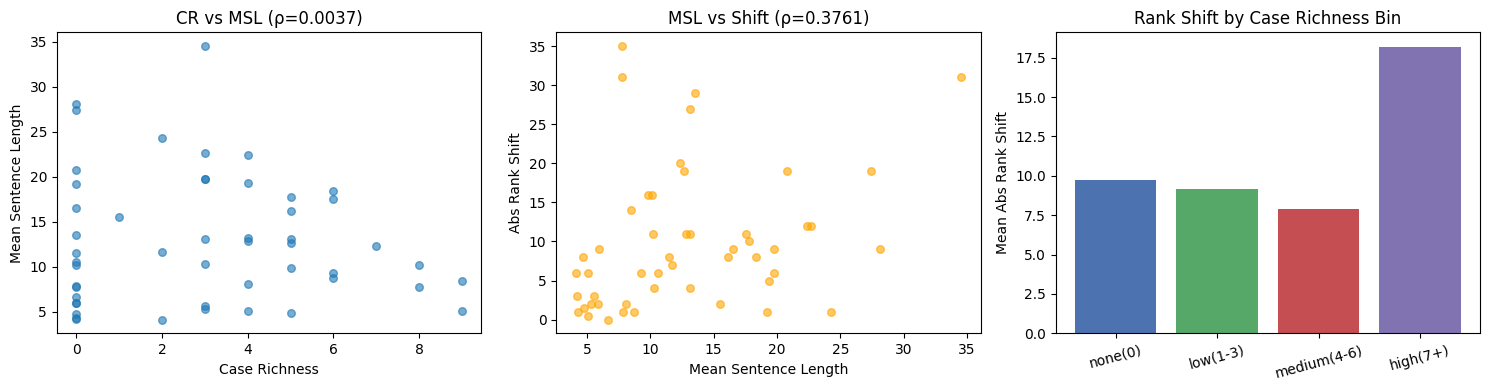

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Case richness vs sentence length
axes[0].scatter(df["cr"], df["msl"], alpha=0.6, s=30)
axes[0].set_xlabel("Case Richness")
axes[0].set_ylabel("Mean Sentence Length")
axes[0].set_title(f"CR vs MSL (ρ={correlations[0].get('spearman_rho', 'N/A')})")

# 2. Sentence length vs abs rank shift
axes[1].scatter(df["msl"], df["abs_rank_shift"], alpha=0.6, s=30, color="orange")
axes[1].set_xlabel("Mean Sentence Length")
axes[1].set_ylabel("Abs Rank Shift")
axes[1].set_title(f"MSL vs Shift (ρ={correlations[2].get('spearman_rho', 'N/A')})")

# 3. Group means by case bin
gs = pd.DataFrame(group_stats)
x_pos = range(len(gs))
axes[2].bar(x_pos, gs["mean_abs_shift"], color=["#4c72b0", "#55a868", "#c44e52", "#8172b2"][:len(gs)])
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(gs["case_bin"], rotation=15)
axes[2].set_ylabel("Mean Abs Rank Shift")
axes[2].set_title("Rank Shift by Case Richness Bin")

plt.tight_layout()
plt.show()